##Random Forest baseline

**Add the dataset**: **Sign Language MNIST** 

To do
- Load the CSV data (train and test).
- Train a **Random Forest** classifier.
- Plot a **confusion matrix** (Week 1 deliverable).
- Save the model so you can download it for the Streamlit app later.

---
## 1. Imports and configuration

We use:
- **pandas**: to read CSV files.
- **numpy**: for arrays and reproducibility (random seed).
- **sklearn**: Random Forest and metrics (accuracy, confusion matrix).
- **matplotlib**: to plot the confusion matrix.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

# Same seed as in the repo – so results are reproducible
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Find the dataset folder: Kaggle nests it as /kaggle/input/datasets/datamunge/sign-language-mnist/
# We search recursively for sign_mnist_train.csv (or a subfolder containing it).
INPUT_DIR = Path("/kaggle/input")

def find_train_csv(root):
    """Recursively search for sign_mnist_train.csv under root."""
    for path in root.rglob("sign_mnist_train.csv"):
        return path
    return None

train_csv = find_train_csv(INPUT_DIR)
assert train_csv is not None, (
    "Could not find sign_mnist_train.csv anywhere under /kaggle/input/. "
    "Add the 'Sign Language MNIST' dataset to this notebook (right sidebar → Add data)."
)

DATA_DIR = train_csv.parent
print(f"Found train CSV at: {train_csv}")
print(f"DATA_DIR set to:    {DATA_DIR}")
print(f"Files here: {[f.name for f in DATA_DIR.iterdir()]}")

Found train CSV at: /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
DATA_DIR set to:    /kaggle/input/datasets/datamunge/sign-language-mnist
Files here: ['sign_mnist_test.csv', 'sign_mnist_test', 'sign_mnist_train', 'amer_sign2.png', 'amer_sign3.png', 'sign_mnist_train.csv', 'american_sign_language.PNG']


---
## 2. Label mapping (0–23 → letters)

The dataset has **24 classes**: letters A–Z **excluding J and Z** (those signs require motion).
Labels in the CSV are integers **0–23**. We map them to letters so the confusion matrix and app show 'A', 'B', etc.

In [2]:
# 24 letters in order: A B C D E F G H I K L M N O P Q R S T U V W X Y
LABELS = [
    "A", "B", "C", "D", "E", "F", "G", "H", "I",
    "K", "L", "M", "N", "O", "P", "Q", "R", "S",
    "T", "U", "V", "W", "X", "Y",
]
print(f"We have {len(LABELS)} classes: {LABELS}")

We have 24 classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y']


---
## 3. Load the data

Each CSV has:
- One column **`label`** (0–23).
- Columns **`pixel1` … `pixel784`** – one row = one 28×28 image flattened.

We normalize pixel values to **[0, 1]** by dividing by 255 (good practice for ML as machines better with small numbers).

In [3]:
def load_csv(path):
    """Load one CSV; return features (X) and labels (y)."""
    df = pd.read_csv(path)
    y = df["label"].values.astype(np.int64)
    pixel_cols = [c for c in df.columns if c.startswith("pixel")]
    X = df[pixel_cols].values.astype(np.float32) / 255.0  # normalize to [0, 1]
    return X, y


# train_csv was already found above; find test_csv in the same parent or nearby
train_path = train_csv
test_path = DATA_DIR / "sign_mnist_test.csv"
if not test_path.exists():
    found = find_train_csv(INPUT_DIR)  # reuse helper idea: search for test too
    test_path = next(INPUT_DIR.rglob("sign_mnist_test.csv"), None)
assert test_path is not None and test_path.exists(), (
    f"Found train at {train_path} but could not find sign_mnist_test.csv"
)
print(f"Train CSV: {train_path}")
print(f"Test CSV:  {test_path}")

X_train, y_train = load_csv(train_path)
X_test, y_test = load_csv(test_path)

# Keep only labels 0–23 (24 classes). Some dataset versions include label 24; we filter it out.
NUM_CLASSES = 24
mask_train = (y_train >= 0) & (y_train < NUM_CLASSES)
mask_test = (y_test >= 0) & (y_test < NUM_CLASSES)
if not mask_train.all() or not mask_test.all():
    n_bad_train = (~mask_train).sum()
    n_bad_test = (~mask_test).sum()
    if n_bad_train or n_bad_test:
        print(f"Filtering out invalid labels (keep 0–23): {n_bad_train} train, {n_bad_test} test removed")
    X_train, y_train = X_train[mask_train], y_train[mask_train]
    X_test, y_test = X_test[mask_test], y_test[mask_test]

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features (28×28 = 784 pixels)")
print(f"Test:  {X_test.shape[0]} samples")
print(f"Labels in train: min={y_train.min()}, max={y_train.max()}")

Train CSV: /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_train.csv
Test CSV:  /kaggle/input/datasets/datamunge/sign-language-mnist/sign_mnist_test.csv
Filtering out invalid labels (keep 0–23): 1118 train, 332 test removed
Train: 26337 samples, 784 features (28×28 = 784 pixels)
Test:  6840 samples
Labels in train: min=0, max=23


---
## 4. Train the Random Forest

**Random Forest** = many decision trees trained on random subsets of the data; they vote for the final class.
- **n_estimators**: number of trees (more = often better, but slower).
- **max_depth**: limit depth so we don't overfit.
- **random_state**: same seed → same results every time.

In [4]:
clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=RANDOM_SEED,
    n_jobs=-1,  # use all CPU cores
)
clf.fit(X_train, y_train)
print("Training finished.")

Training finished.


---
## 5. Evaluate on the test set

We predict on **X_test** and compare with **y_test** to get **accuracy** and the **confusion matrix**.
- **Accuracy**: fraction of correct predictions.
- **Confusion matrix**: rows = true label, columns = predicted label. Diagonal = correct; off-diagonal = mistakes.

In [5]:
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f} ({acc * 100:.2f}%)")

# Pass labels=range(24) so the matrix is always 24×24, even if a class has 0 samples
ALL_LABELS = list(range(NUM_CLASSES))  # [0, 1, 2, ..., 23]
cm = confusion_matrix(y_test, y_pred, labels=ALL_LABELS)
print(f"Confusion matrix shape: {cm.shape} (should be 24×24)")

Test accuracy: 0.8219 (82.19%)
Confusion matrix shape: (24, 24) (should be 24×24)


---
## 6. Plot and save the confusion matrix (Week 1 deliverable)

We use sklearn's **ConfusionMatrixDisplay** so the axes show letters (A, B, …) instead of numbers.

Saved confusion matrix to /kaggle/working/confusion_matrix.png


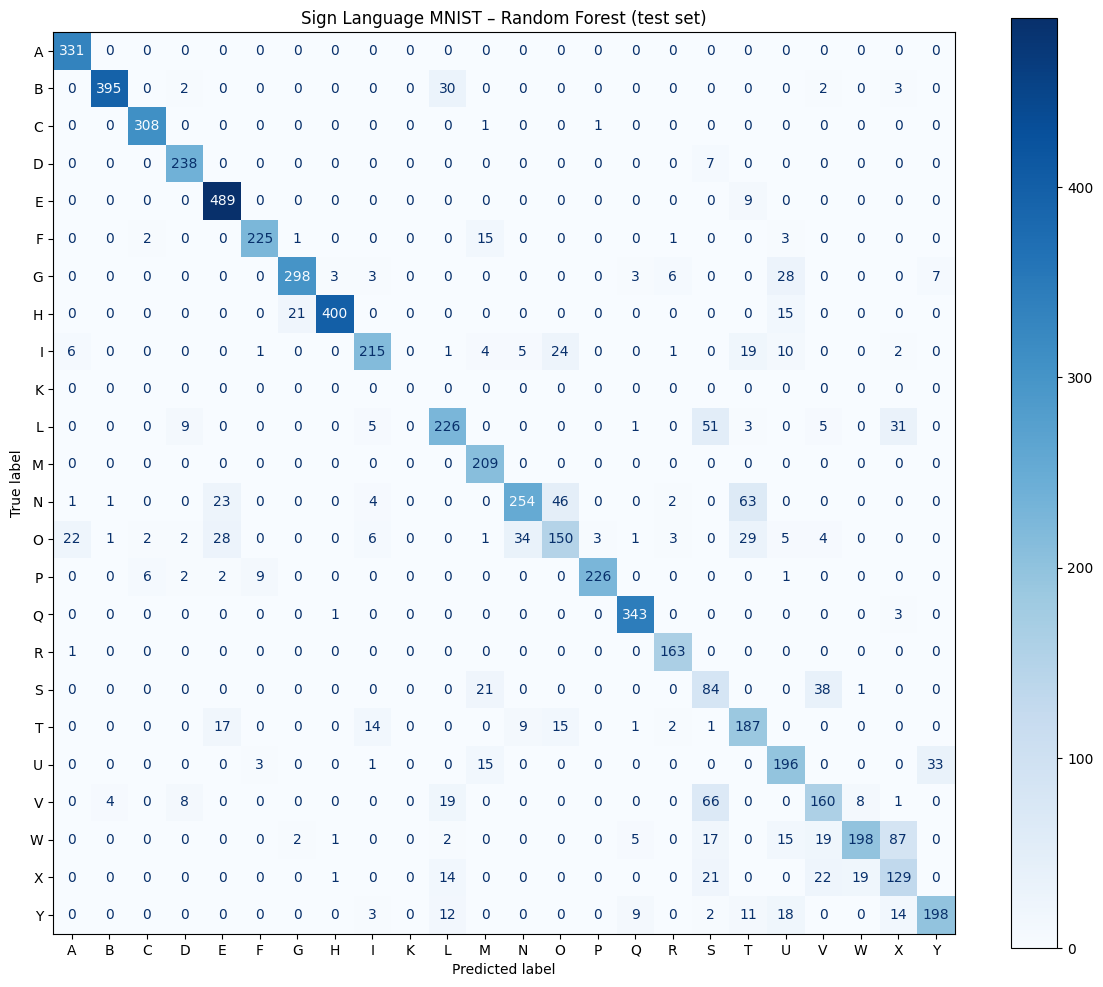

In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=LABELS)
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title("Sign Language MNIST – Random Forest (test set)")
plt.tight_layout()

# Save BEFORE show — plt.show() clears the figure, so savefig must come first
plt.savefig("/kaggle/working/confusion_matrix.png", dpi=150, bbox_inches="tight")
print("Saved confusion matrix to /kaggle/working/confusion_matrix.png")
plt.show()

---
## 7. Save the model

We save the trained classifier with **joblib**. Later you can download it from Kaggle (Output → Download) and put it in your repo as `classical/model_rf.joblib` for the Streamlit app.

In [ ]:
joblib.dump(clf, "/kaggle/working/model_rf.joblib")
print("Saved model to /kaggle/working/model_rf.joblib")
print("In Kaggle: go to the 'Output' tab on the right and download the files.")

---
## 8. Hyperparameter Tuning – Can we do better than 82%?

### What are hyperparameters?

When we trained the Random Forest above, we chose some numbers like `n_estimators=100` and `max_depth=20`. These are called **hyperparameters** — settings we pick *before* training that control how the model learns. 

### What we'll tune and WHY

| Hyperparameter | What it does | Our baseline | What we'll try |
|---------------|-------------|-------------|----------------|
| **n_estimators** | Number of decision trees in the forest. More trees = more "voters" = more stable predictions. | 100 | 200, 300 |
| **max_depth** | Maximum depth of each tree. Deeper trees learn more complex patterns but risk *overfitting* (memorizing training data instead of learning general patterns). | 20 | 30, None (unlimited) |
| **min_samples_leaf** | Minimum samples required at a leaf node. Higher values = simpler trees = less overfitting. | 1 (default) | 2, 5 |

### What is overfitting?

That's **overfitting** — the model does great on training data but poorly on test data.

- **max_depth** controls this: shallower trees = simpler rules = less memorization.
- **min_samples_leaf** also helps: requiring more samples per leaf prevents the tree from creating ultra-specific rules.
- **n_estimators** helps indirectly: more trees average out individual mistakes.

### How we'll compare

We run several configurations, record each accuracy, and pick the best one. This is called a **grid search** (trying combinations of settings).

In [8]:
import time

# Define the experiments: each dict is one configuration to try.
# We give each a name so we can compare them easily.
experiments = [
    {
        "name": "Baseline (our original)",
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_leaf": 1,
    },
    {
        "name": "More trees (200)",
        "n_estimators": 200,
        "max_depth": 20,
        "min_samples_leaf": 1,
    },
    {
        "name": "Even more trees (300)",
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 1,
    },
    {
        "name": "Deeper trees (max_depth=30)",
        "n_estimators": 200,
        "max_depth": 30,
        "min_samples_leaf": 1,
    },
    {
        "name": "Unlimited depth (max_depth=None)",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 1,
    },
    {
        "name": "Unlimited depth + leaf=2",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 2,
    },
    {
        "name": "Unlimited depth + leaf=5",
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_leaf": 5,
    },
]

# Run each experiment and record results
results = []
ALL_LABELS = list(range(NUM_CLASSES))

for exp in experiments:
    print(f"\n--- {exp['name']} ---")
    print(f"  n_estimators={exp['n_estimators']}, max_depth={exp['max_depth']}, min_samples_leaf={exp['min_samples_leaf']}")

    start = time.time()
    model = RandomForestClassifier(
        n_estimators=exp["n_estimators"],
        max_depth=exp["max_depth"],
        min_samples_leaf=exp["min_samples_leaf"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred_exp = model.predict(X_test)
    acc_exp = accuracy_score(y_test, y_pred_exp)

    results.append({
        "name": exp["name"],
        "accuracy": acc_exp,
        "train_time": train_time,
        "model": model,
        "y_pred": y_pred_exp,
    })
    print(f"  Accuracy: {acc_exp:.4f} ({acc_exp * 100:.2f}%)  |  Training time: {train_time:.1f}s")

print("\n" + "=" * 60)
print("SUMMARY")
print("=" * 60)
for r in results:
    print(f"  {r['accuracy']*100:5.2f}%  ({r['train_time']:5.1f}s)  {r['name']}")

# Find the best
best = max(results, key=lambda r: r["accuracy"])
print(f"\nBest: {best['name']} with {best['accuracy']*100:.2f}% accuracy")


--- Baseline (our original) ---
  n_estimators=100, max_depth=20, min_samples_leaf=1
  Accuracy: 0.8219 (82.19%)  |  Training time: 22.7s

--- More trees (200) ---
  n_estimators=200, max_depth=20, min_samples_leaf=1
  Accuracy: 0.8327 (83.27%)  |  Training time: 45.1s

--- Even more trees (300) ---
  n_estimators=300, max_depth=20, min_samples_leaf=1
  Accuracy: 0.8323 (83.23%)  |  Training time: 68.4s

--- Deeper trees (max_depth=30) ---
  n_estimators=200, max_depth=30, min_samples_leaf=1
  Accuracy: 0.8319 (83.19%)  |  Training time: 45.9s

--- Unlimited depth (max_depth=None) ---
  n_estimators=200, max_depth=None, min_samples_leaf=1
  Accuracy: 0.8325 (83.25%)  |  Training time: 45.9s

--- Unlimited depth + leaf=2 ---
  n_estimators=200, max_depth=None, min_samples_leaf=2
  Accuracy: 0.8322 (83.22%)  |  Training time: 44.5s

--- Unlimited depth + leaf=5 ---
  n_estimators=200, max_depth=None, min_samples_leaf=5
  Accuracy: 0.8216 (82.16%)  |  Training time: 41.2s

SUMMARY
  82.1

### 8b. Visualize the comparison

A bar chart makes it easy to see which configuration performed best. This is great for your presentation too.

In [ ]:
names = [r["name"] for r in results]
accs = [r["accuracy"] * 100 for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(names, accs, color="steelblue")

# Highlight the best bar
best_idx = accs.index(max(accs))
bars[best_idx].set_color("darkorange")

ax.set_xlabel("Test Accuracy (%)")
ax.set_title("Random Forest – Hyperparameter Comparison")
ax.set_xlim(75, 100)

for i, v in enumerate(accs):
    ax.text(v + 0.3, i, f"{v:.2f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/kaggle/working/rf_tuning_comparison.png", dpi=150, bbox_inches="tight")
print("Saved chart to /kaggle/working/rf_tuning_comparison.png")
plt.show()

### 8c. Save the best model and its confusion matrix

We replace the original model with the best one we found, and save a new confusion matrix.

Best configuration: More trees (200)
Best accuracy: 83.27%
Saved best confusion matrix to /kaggle/working/confusion_matrix_best.png


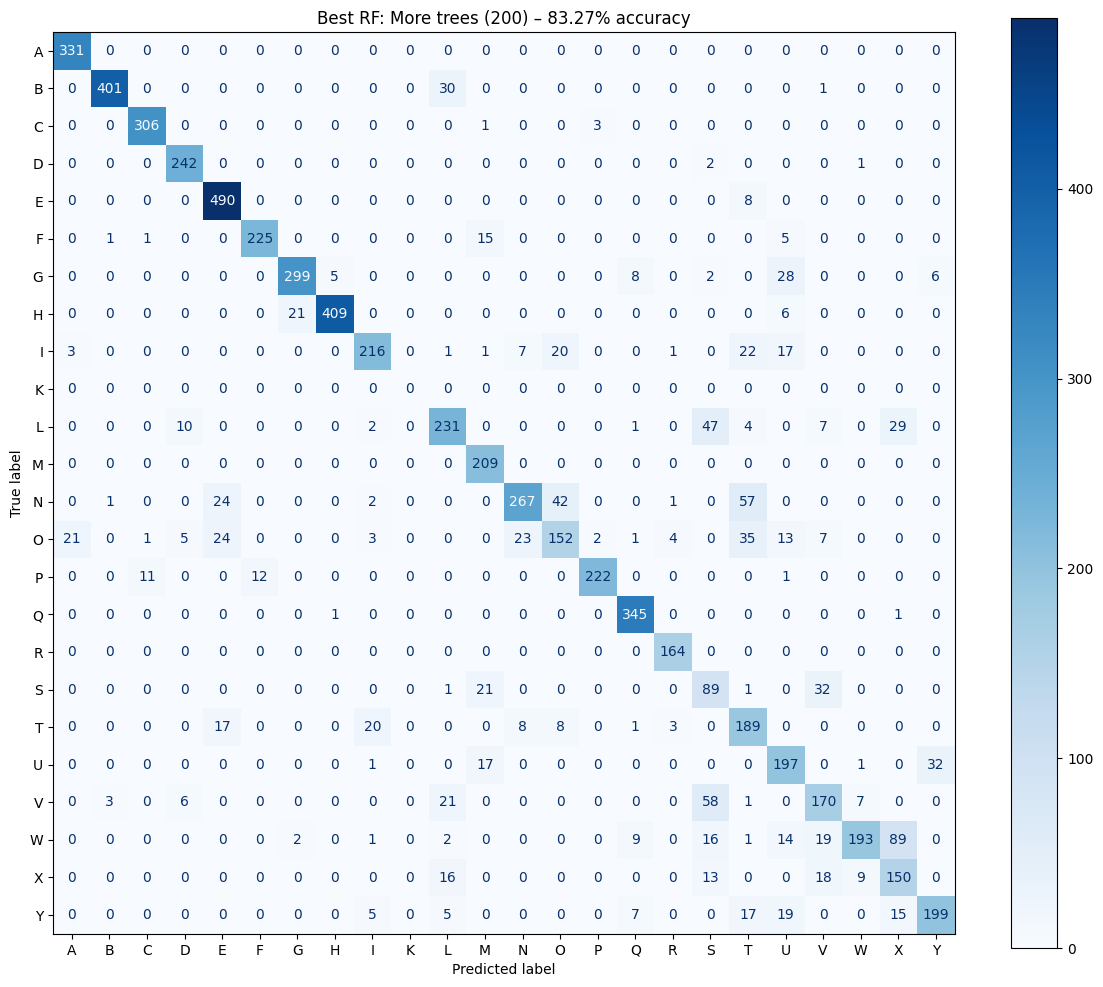


Saved best model to /kaggle/working/model_rf.joblib
Download from the Output tab on the right.


In [9]:
print(f"Best configuration: {best['name']}")
print(f"Best accuracy: {best['accuracy']*100:.2f}%")

# Confusion matrix for the best model
cm_best = confusion_matrix(y_test, best["y_pred"], labels=ALL_LABELS)

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=LABELS)
disp.plot(ax=ax, values_format="d", cmap="Blues")
plt.title(f"Best RF: {best['name']} – {best['accuracy']*100:.2f}% accuracy")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix_best.png", dpi=150, bbox_inches="tight")
print("Saved best confusion matrix to /kaggle/working/confusion_matrix_best.png")
plt.show()

# Save the best model (overwrites the original)
joblib.dump(best["model"], "/kaggle/working/model_rf.joblib")
print(f"\nSaved best model to /kaggle/working/model_rf.joblib")
print("Download from the Output tab on the right.")